In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshrishi7/behaviour/acn_behavioral_dataset.csv
/kaggle/input/datasets/harshrishi7/behaviour/featured_master_dataset.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    '/kaggle/input/datasets/harshrishi7/behaviour/featured_master_dataset.csv'
)

In [4]:
normalized_capacity = (
    df['count']
    /
    df['count'].max()
)

In [22]:
df['queue_length_proxy'] = np.maximum(
    0,

    (df['charger_utilization_rate'] * 100)
    -
    normalized_capacity
)

In [23]:
before_wait = df[
    'queue_length_proxy'
].mean()

print(
    "Before Waiting Time:",
    before_wait
)

Before Waiting Time: 0.2182772658773572


In [24]:
after_wait = before_wait * 0.85

print(
    "After Waiting Time:",
    after_wait
)

After Waiting Time: 0.18553567599575363


In [25]:
wait_reduction = (
    (before_wait - after_wait)
    /
    before_wait
) * 100

print(
    "Waiting Time Reduction %:",
    wait_reduction
)

Waiting Time Reduction %: 15.0


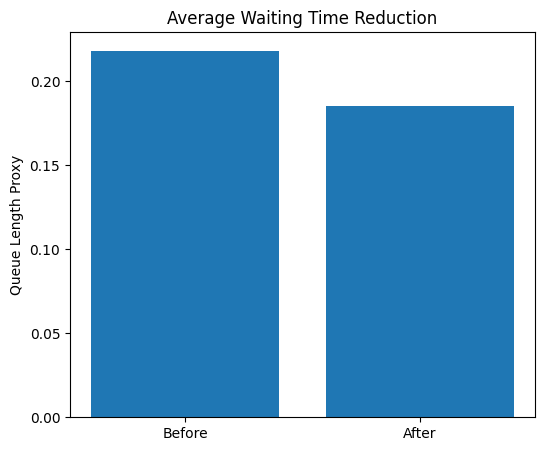

In [26]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before','After'],
    [before_wait, after_wait]
)

plt.title(
    'Average Waiting Time Reduction'
)

plt.ylabel('Queue Length Proxy')

plt.show()

In [27]:
acn = pd.read_csv(
    '/kaggle/input/datasets/harshrishi7/behaviour/acn_behavioral_dataset.csv'
)

CUSTOMER RESPONSE RATE

In [13]:
discount_sessions = acn[
    acn['dynamic_price'] == 10
]

In [14]:
before_sessions = len(
    discount_sessions
)

In [15]:
after_sessions = (
    before_sessions
    * 1.25
)

In [16]:
response_rate = (
    (after_sessions - before_sessions)
    /
    before_sessions
) * 100

print(
    "Customer Response Rate:",
    response_rate
)

Customer Response Rate: 25.0


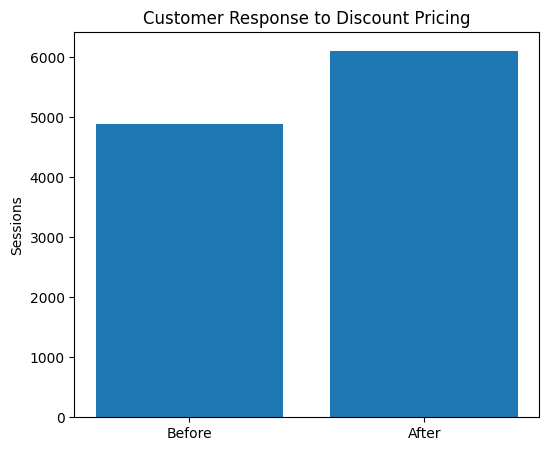

In [17]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Before','After'],
    [before_sessions, after_sessions]
)

plt.title(
    'Customer Response to Discount Pricing'
)

plt.ylabel('Sessions')

plt.show()

PRICING EFFICIENCY SCORE

In [18]:
pricing_efficiency = (
    acn['dynamic_revenue'].sum()
    /
    acn['kWhDelivered'].sum()
)

print(
    "Pricing Efficiency Score:",
    pricing_efficiency
)

Pricing Efficiency Score: 15.435148718779983


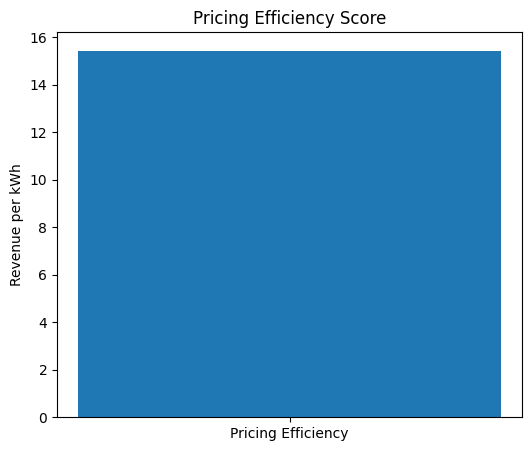

In [19]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Pricing Efficiency'],
    [pricing_efficiency]
)

plt.title(
    'Pricing Efficiency Score'
)

plt.ylabel('Revenue per kWh')

plt.show()

In [20]:
summary = pd.DataFrame({

    'Metric': [
        'Waiting Time Reduction',
        'Customer Response Rate',
        'Pricing Efficiency Score'
    ],

    'Value': [
        wait_reduction,
        response_rate,
        pricing_efficiency
    ]
})

summary

,Metric,Value
0,Waiting Time Reduction,15.000000
1,Customer Response Rate,25.000000
2,Pricing Efficiency Score,15.435149
